# **Dual-Model Testing Grounds**

This notebook was made in pure interest of exploring how different models may be able to work in conjunction with one another through a shared interface to illustrate some sort of purpose.

Exploring the concept of the Turing test and comparing human-written and AI-generated language, I wanted to produce a side-by-side comparison of an AI vs. human response to the same prompt to compare metrics.

# **Setup**

In [ ]:
!pip install -q huggingface_hub gradio

In [ ]:
!pip install transformers torch accelerate

In [2]:
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoConfig, AutoModel, PreTrainedModel, pipeline
from huggingface_hub import InferenceClient
import gradio as gr

# **Detector Model**

Used in this example:

[desklib's AI Text Detector V1.01](https://huggingface.co/desklib/ai-text-detector-v1.01), a fine-tuned version of Microsoft's DeBERTa v3 Large for classifying English text as human-written or AI-generated.

**Direct Loading**:

For demo purposes: no pipeline, using auto-config, setup, and inference examples from the "Usage" section from source page

[Reference](https://huggingface.co/desklib/ai-text-detector-v1.01?library=transformers)

Class + Functions:

In [3]:
class DesklibAIDetectionModel(PreTrainedModel):
    config_class = AutoConfig

    def __init__(self, config):
        super().__init__(config)
        # Initialize the base transformer model.
        self.model = AutoModel.from_config(config)
        # Define a classifier head.
        self.classifier = nn.Linear(config.hidden_size, 1)
        # Initialize weights (handled by PreTrainedModel)
        self.init_weights()

        # fixed transformers version-based AttributeError
        #ref: https://github.com/AnswerDotAI/rerankers/issues/77
        self.post_init()

    def forward(self, input_ids, attention_mask=None, labels=None):
        # Forward pass through the transformer
        outputs = self.model(input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs[0]
        # Mean pooling
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        pooled_output = sum_embeddings / sum_mask

        # Classifier
        logits = self.classifier(pooled_output)
        loss = None
        if labels is not None:
            loss_fct = nn.BCEWithLogitsLoss()
            loss = loss_fct(logits.view(-1), labels.float())

        output = {"logits": logits}
        if loss is not None:
            output["loss"] = loss
        return output

In [4]:
def predict_single_text(text, model, tokenizer, device, max_len=768, threshold=0.5):
    encoded = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs["logits"]
        probability = torch.sigmoid(logits).item()

    label = 1 if probability >= threshold else 0
    return probability, label


Extracted from example **main()**:

In [5]:
# --- Model and Tokenizer Directory ---
model_directory = "desklib/ai-text-detector-v1.01"

# --- Load tokenizer and model ---
tokenizer = AutoTokenizer.from_pretrained(model_directory)
cls_model = DesklibAIDetectionModel.from_pretrained(model_directory)

# --- Set up device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cls_model.to(device)


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.74GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

DesklibAIDetectionModel(
  (model): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 1024, padding_idx=0)
      (LayerNorm): LayerNorm((1024,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-23): 24 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (key_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (value_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNor

In [ ]:
# --- Example Input text ---
text_ai = "AI detection refers to the process of identifying whether a given piece of content, such as text, images, or audio, has been generated by artificial intelligence. This is achieved using various machine learning techniques, including perplexity analysis, entropy measurements, linguistic pattern recognition, and neural network classifiers trained on human and AI-generated data. Advanced AI detection tools assess writing style, coherence, and statistical properties to determine the likelihood of AI involvement. These tools are widely used in academia, journalism, and content moderation to ensure originality, prevent misinformation, and maintain ethical standards. As AI-generated content becomes increasingly sophisticated, AI detection methods continue to evolve, integrating deep learning models and ensemble techniques for improved accuracy."
text_human = "It is estimated that a major part of the content in the internet will be generated by AI / LLMs by 2025. This leads to a lot of misinformation and credibility related issues. That is why if is important to have accurate tools to identify if a content is AI generated or human written"

In [ ]:
# --- Run prediction ---
probability, predicted_label = predict_single_text(text_ai, cls_model, tokenizer, device)

print(f"Probability of being AI generated: {probability:.4f}")
print(f"Predicted label: {'AI Generated' if predicted_label == 1 else 'Not AI Generated'}")

probability, predicted_label = predict_single_text(text_human, cls_model, tokenizer, device)
print(f"Probability of being AI generated: {probability:.4f}")
print(f"Predicted label: {'AI Generated' if predicted_label == 1 else 'Not AI Generated'}")

Probability of being AI generated: 0.9974
Predicted label: AI Generated
Probability of being AI generated: 0.4245
Predicted label: Not AI Generated


Self-Examples:

In [ ]:
# Formal, report/announcement
ex_1 = "According to the report received by our team from Central Headquarters at 9:55 P.M. EST last night, Mr. Texas and Mrs. Alabama have been officially pronounced dead. Further updates to follow."

# Casual conversation, phone conversation or text transcript
ex_2 = "yeah, it was crazyyyy bro. both of em, DEAD. like, DEEEEED. i didn't think it was possible to take down those gonks but anything goes in nc, i guess"

# Casual, call for attention
ex_3 = "HEY YOU, YEAH YOU! Over here!!! HEYYYYYYYYYY!!!! DON'T IGNORE ME."

In [ ]:
probability, predicted_label = predict_single_text(ex_1, cls_model, tokenizer, device)
print(f"AI Detection Score: {probability:.4f}")
print(f"Diagnosis: {'AI Generated' if predicted_label == 1 else 'Not AI Generated'}")

probability, predicted_label = predict_single_text(ex_2, cls_model, tokenizer, device)
print(f"AI Detection Score: {probability:.4f}")
print(f"Diagnosis: {'AI Generated' if predicted_label == 1 else 'Not AI Generated'}")

probability, predicted_label = predict_single_text(ex_3, cls_model, tokenizer, device)
print(f"AI Detection Score: {probability:.4f}")
print(f"Diagnosis: {'AI Generated' if predicted_label == 1 else 'Not AI Generated'}")

AI Detection Score: 0.9702
Diagnosis: AI Generated
AI Detection Score: 0.3992
Diagnosis: Not AI Generated
AI Detection Score: 0.8443
Diagnosis: AI Generated


Self-examples comparison to an online AI text-detection tool, using Example #1 (formal-sounding, report):

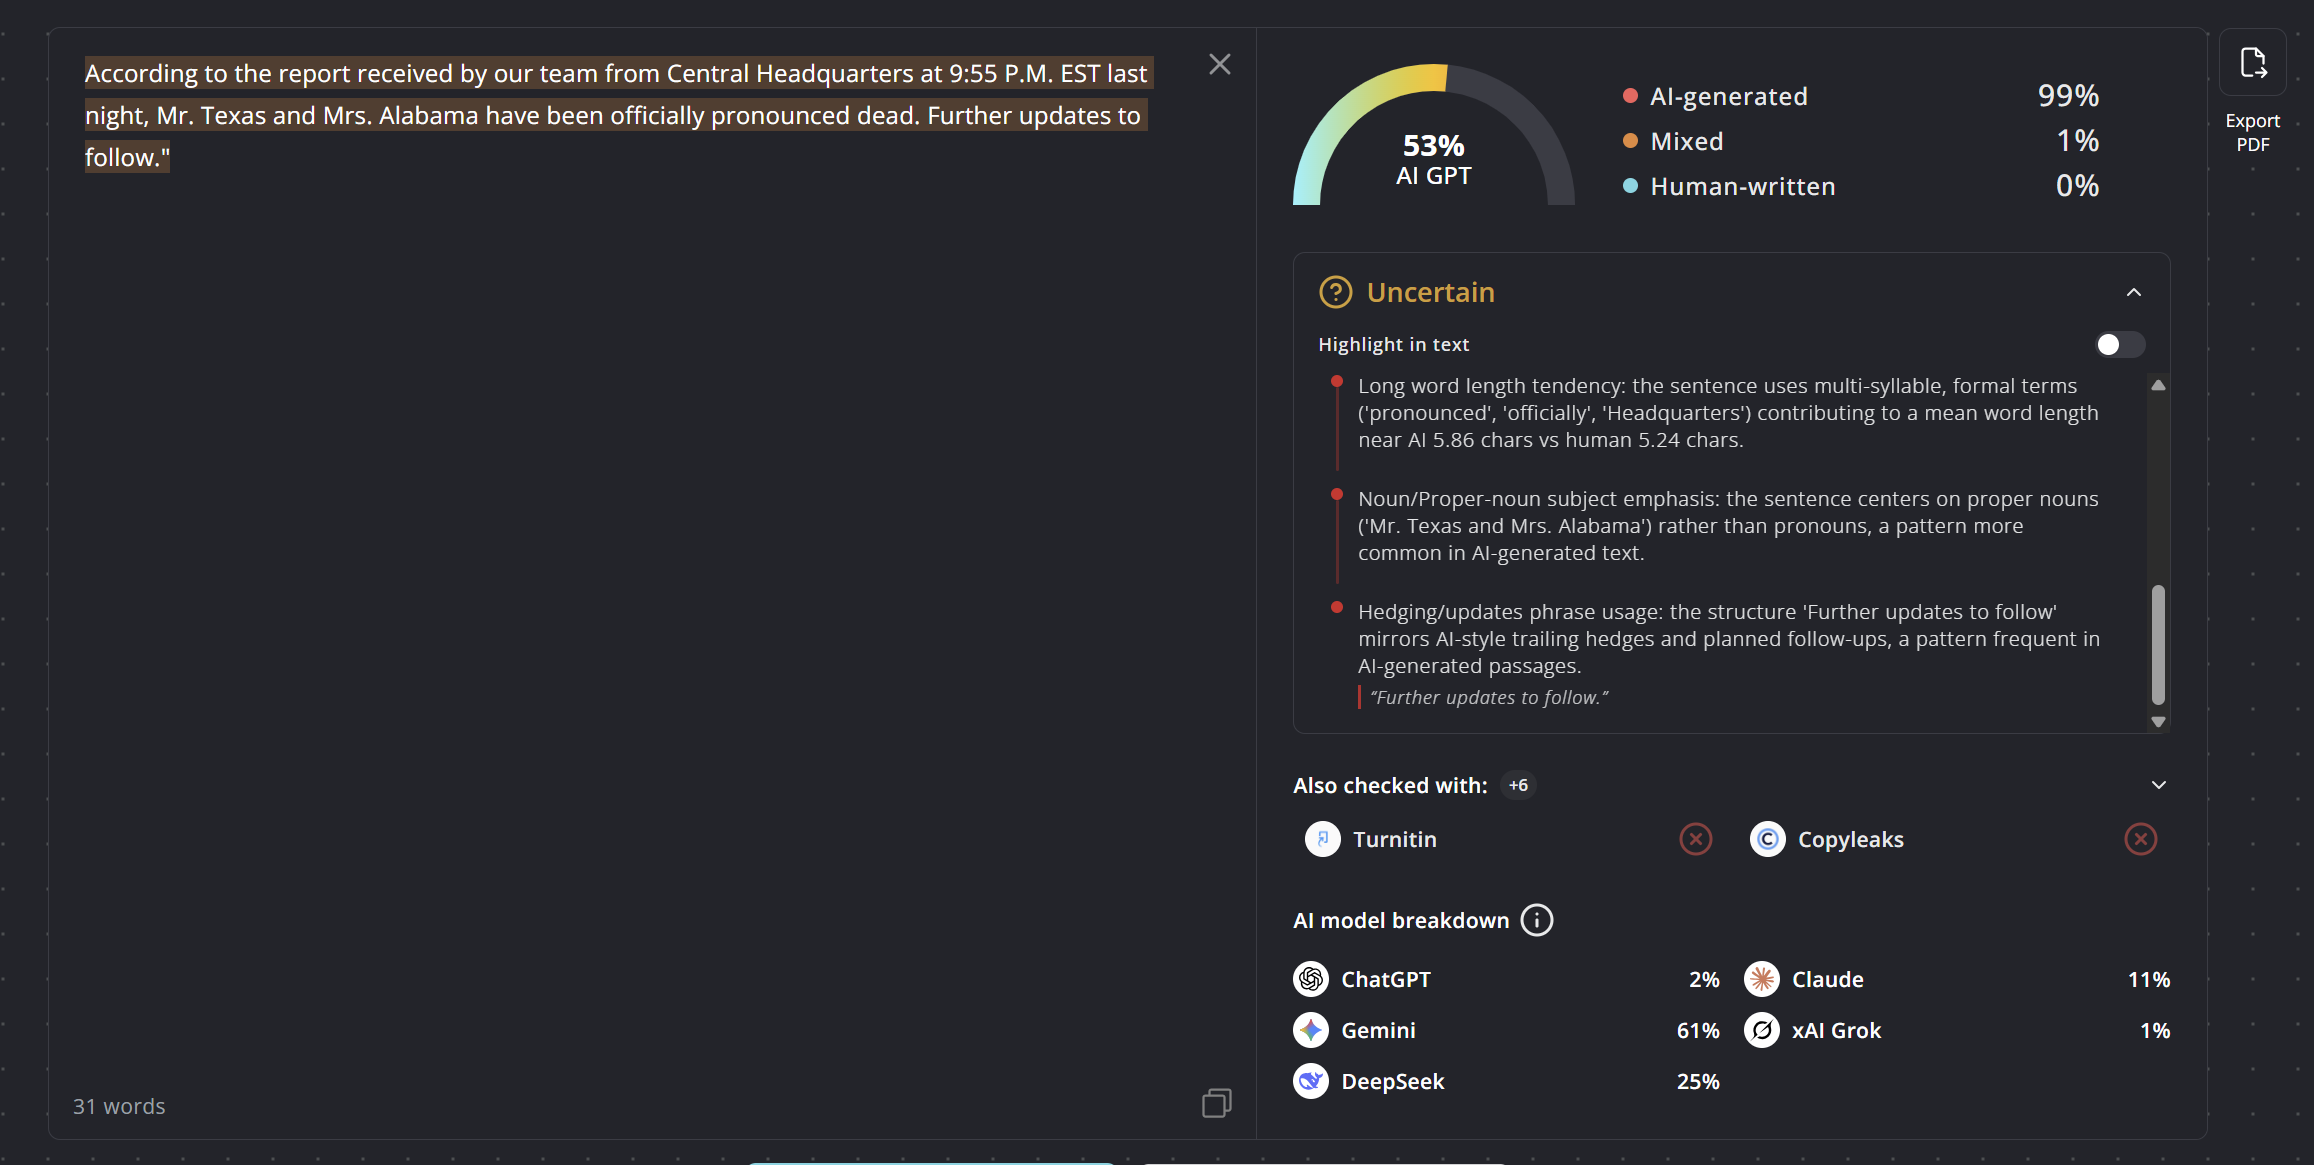

When the online tool "Humanized" the text so that it passed typical evaluation patterns: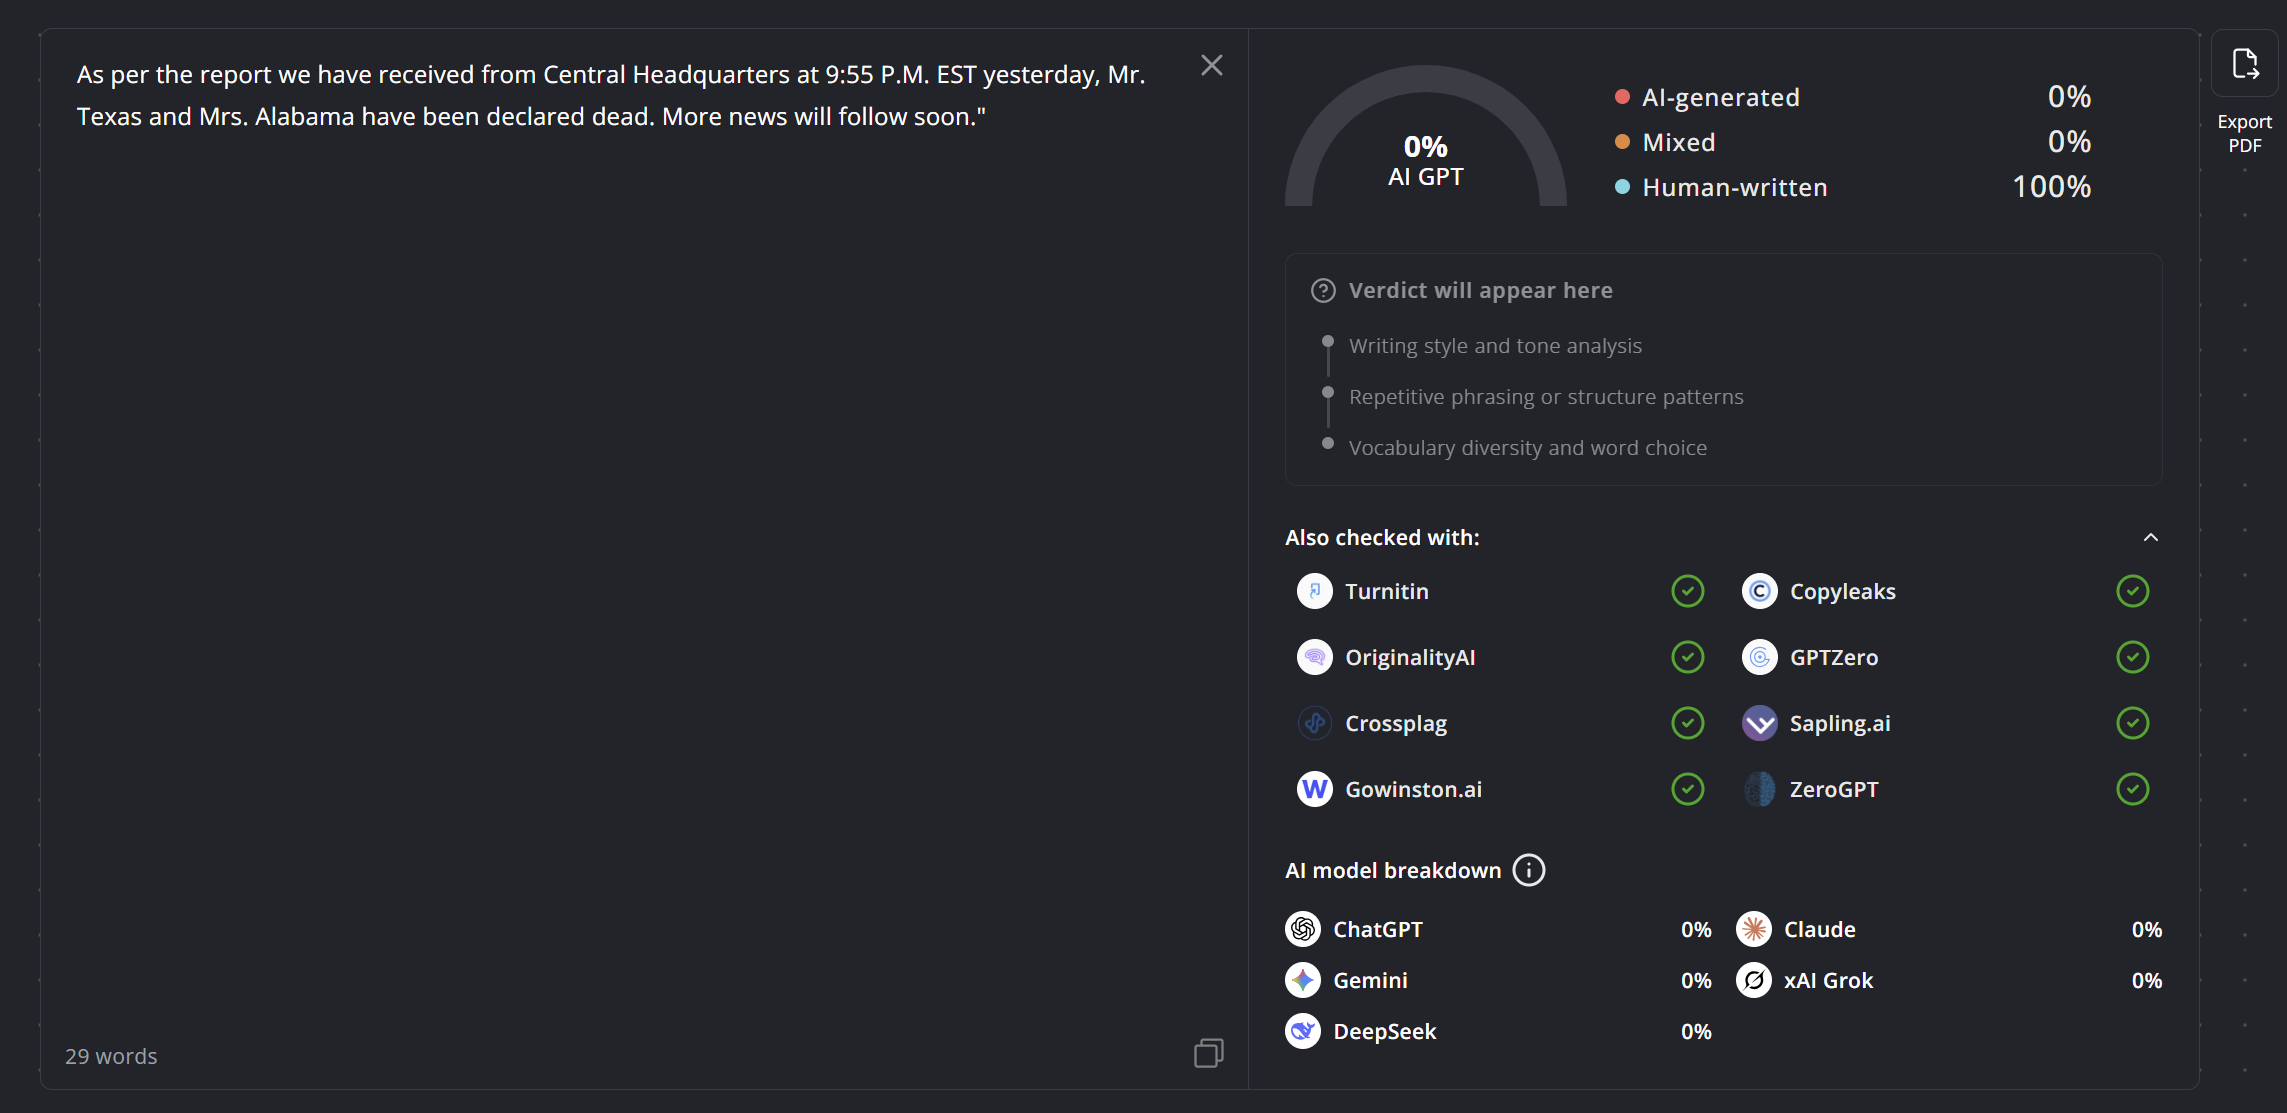

# **Conversational Model:**

Used in this example:

[Qwen 2.5 7B Instruct](https://huggingface.co/Qwen/Qwen2.5-7B-Instruct)


**HuggingFace Serverless API for Testing Gen Model:**

[Reference](https://huggingface.co/agents-course/notebooks/blob/main/unit1/dummy_agent_library.ipynb)

I was unsure if installing/deploying a big model would interfere with running these experiments due to free GPU limitations, so I used HuggingFace's serverless API to load in the model and run inference :,)

In [6]:
try:
  from google.colab import userdata
  HF_TOKEN = userdata.get("HF_TOKEN")
except ImportError:
  HF_TOKEN = os.environ.get("HF_TOKEN")

In [7]:
gen_model = "Qwen/Qwen2.5-7B-Instruct"

client = InferenceClient(gen_model, token=HF_TOKEN)

**Sample Context for RAG**

Group note:

(NLP Week 2: this is where we would make a knowledge base, use embeddings to build an indexing system to retrieve appropriate contexts)

- Fixed round-based question/prompt system??

In [8]:
# sample context about Amanita mushrooms to test the text-generation while lacking documents
sample_context = (
    "The Amanita genus of agarics contains roughly 600 species, including both edible species and some of the most toxic mushrooms in the world."
)

sample_query = "What is an Amanita mushroom?"

sample_convo = [
    {
      "role": "system",
      "content": f"Respond to the query based on the context: {sample_context}"
    },
    {
      "role": "user",
      "content": sample_query
    }
]

In [ ]:
response = client.chat.completions.create(
    model=gen_model,
    messages=sample_convo,
    max_tokens=150,
)

result = response.choices[0].message.content
print("LLM Response:", result)

LLM Response: An Amanita mushroom is a type of agaric fungus within the genus Amanita, which comprises approximately 600 species. This genus includes both edible species that are prized in cuisine and some of the most toxic mushrooms found in the world.


In [ ]:
sample_context = (
    "The Amanita genus of agarics contains roughly 600 species, including both edible species and some of the most toxic mushrooms in the world."
)
sample_query = "Can I eat an Amanita mushroom?" # new question
sample_convo = [
    {
      "role": "system",
      "content": f"Respond to the query based on the context: {sample_context}"
    },
    {
      "role": "user",
      "content": sample_query
    }
]

response = client.chat.completions.create(
    model=gen_model,
    messages=sample_convo,
    max_tokens=150,
) # could also play with "temperature" parameter

result = response.choices[0].message.content
print("LLM Response:", result)

LLM Response: No, you should not eat Amanita mushrooms without proper identification, as many species in this genus are highly toxic. It's important to consult with an expert mycologist or a reliable field guide to ensure the safety of any mushrooms you plan to consume.


# **Output Testings**

Testing the Qwen chat model's output on the desklib detector model:

In [ ]:
gen_res_1 = "An Amanita mushroom is a type of agaric fungus within the genus Amanita, which comprises approximately 600 species. This genus includes both edible species that are prized in cuisine and some of the most toxic mushrooms found in the world."

gen_res_2 = "No, you should not eat Amanita mushrooms without proper identification, as many species in this genus are highly toxic. It's important to consult with an expert mycologist or a reliable field guide to ensure the safety of any mushrooms you plan to consume."

In [ ]:
probability, predicted_label = predict_single_text(gen_res_1, cls_model, tokenizer, device)

print(f"Probability of being AI generated: {probability:.4f}")
print(f"Predicted label: {'AI Generated' if predicted_label == 1 else 'Not AI Generated'}")

probability, predicted_label = predict_single_text(gen_res_2, cls_model, tokenizer, device)

print(f"Probability of being AI generated: {probability:.4f}")
print(f"Predicted label: {'AI Generated' if predicted_label == 1 else 'Not AI Generated'}")

Probability of being AI generated: 0.7106
Predicted label: AI Generated
Probability of being AI generated: 0.9996
Predicted label: AI Generated


vs. simlar self-written text, answering the same questions:

In [ ]:
self_res_1 = "An Amanita mushroom is a fungus within the Amanita genus, known for having some of the most toxic, lethal mushroom species worldwide."

self_res_2 = "DO NOT EAT AN AMANITA MUSHROOM, not until a professional gives you the go-ahead! Amanitas are responsible for 95% of mushroom-related deaths, you know!"

In [ ]:
probability, predicted_label = predict_single_text(self_res_1, cls_model, tokenizer, device)

print(f"Probability of being AI generated: {probability:.4f}")
print(f"Predicted label: {'AI Generated' if predicted_label == 1 else 'Not AI Generated'}")

probability, predicted_label = predict_single_text(self_res_2, cls_model, tokenizer, device)

print(f"Probability of being AI generated: {probability:.4f}")
print(f"Predicted label: {'AI Generated' if predicted_label == 1 else 'Not AI Generated'}")

Probability of being AI generated: 0.9929
Predicted label: AI Generated
Probability of being AI generated: 0.5131
Predicted label: AI Generated


# **Gradio UI**

Example application: Live Turing-test investigation where a chatbot and a human submit responses to the same prompt and are evaluated by a strong AI-detection model.

Somewhat of a investigative game/experiment, a user can measure up how their natural responses score against a powerful conversational model and observe how linguistic tendencies may affect perception of what is AI, an what is naturally human.

Local app-hosting for debugging + public share link to test with group

[Rough reference](https://medium.com/@obandoandrew8/deploying-a-ml-model-with-gradio-and-hugging-face-python-machine-learning-83f076c58a0c), [Gradio Docs](https://gradio.app/guides/quickstart)

Note: Gradio is paywalled on HuggingFace Spaces now 🤕 ....find a solution for that idk

In [26]:
# sample query and spoon-fed matching contexts for demo purposes (no knowledgebase or documents yet, so answers will be very limited)

sample_queries = [
    "How are you feeling right now?",
    "Do you think robots will take over the world?",
    "What is the meaning of life to you?"
]

sample_contexts = [
    "Today was a mediocre day filled with errands and adult responsibilities, but it's finally time to relax, so it could always be worse.",
    "Technological development is rampant and unavoidable; humans have authored multiple cautionary tales regarding the rise of technology into hypothetical dystopia.",
    "In Douglas Adams' science fiction series, The Hitchhiker's Guide to the Galaxy, the answer to the ultimate question is 42."
]

In [31]:
def evaluate_responses(user_response, current_index):

  # fetch the matching context to the current query
  query = sample_queries[current_index]
  context = sample_contexts[current_index]

  sample_convo = [
      {
        "role": "system",
        "content": f"Respond to the query, role-playing in first-person as a normal person answering, adapting to the given context: {context}"
      },
      {
        "role": "user",
        "content": query
      }
  ]

  # handle gen model response

  gen_response = client.chat.completions.create(
      model=gen_model,
      messages=sample_convo,
      max_tokens=200,
      temperature=0.5
  ) # play with temperatures later on?

  gen_result = gen_response.choices[0].message.content

  gen_score, gen_label = predict_single_text(gen_result, cls_model, tokenizer, device)
  gen_percentage = round(gen_score * 100, 2)

  # handle user responses

  user_score, user_label = predict_single_text(user_response, cls_model, tokenizer, device)
  user_percentage = round(user_score * 100, 2)

  # display a metrics board

  metrics_display = (
      f"Question #{current_index + 1}: {query}\n\n"

      f"USER EVALUATION:\n"
      f"Verdict: {'AI Generated' if user_label == 1 else 'Not AI Generated'}\n"
      f"Detection Confidence: {user_percentage}%\n\n"

      f"QWEN MODEL EVALUATION:\n"
      f"Verdict: {'AI Generated' if gen_label == 1 else 'Not AI Generated'}\n"
      f"Detection Confidence: {gen_percentage}%\n"
  )

  return gen_result, metrics_display



In [28]:
# question state
def next_question(current_index):

  # prevent out of bounds by looping back questions
  next_index = (current_index + 1) % len(sample_queries)
  next_question = sample_queries[next_index]

  # update ui
  return (
      next_index, #new current_query_state
      f"## Question #{next_index +1}: {next_question}",  #question_display
      "", # reset user input_box
      "", # reset model output_box
      ""  # reset metrics display
  )


Revised UI for question state demo: [State in Gradio blocks](https://gradio.app/guides/state-in-blocks)

In [32]:
with gr.Blocks() as demo:

  # session state to track question index (passing default value)
  current_query_state = gr.State(value=0)

  gr.Markdown(
  """
  # Dual-Model Example
  How AI do you write?
  """)

  question_display = gr.Markdown(f"## Question #1: {sample_queries[0]}")

  with gr.Row():
    # human-input section
    with gr.Column(scale=1):
      gr.Markdown("### User Response Area")
      input_box = gr.Textbox(
          label="Your Text Input",
          placeholder="Answer the question above! Be natural...?",
          lines=5
      )
      submit_button = gr.Button("Submit Response", variant="primary")

    # gen-input section
    with gr.Column(scale=1):
      gr.Markdown("### Generative Model Area")
      output_box = gr.Textbox(label="Qwen-2.5-7B-Instruct Text Output", interactive=False, lines=5)

  with gr.Row():
    with gr.Column():
      # display metrics
      metrics = gr.Code(label="Fine-tuned DeBERTA Detection Model Results")

      # next question, swap state
      next_question_button = gr.Button("Next Question", variant="secondary")

  # basic event, state

  submit_button.click(
      fn=evaluate_responses,
      inputs=[input_box, current_query_state],
      outputs=[output_box, metrics]
  )

  # advance through question sequence

  next_question_button.click(
      fn=next_question,
      inputs=[current_query_state],
      outputs=[current_query_state, question_display, input_box, output_box, metrics]
  )

Note: Demo will work, but can take some time to process😵 (for me, it's averaged 40-50s)

In [ ]:
demo.launch(theme=gr.themes.Soft(), debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bd4331b484cef628b6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
